In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
train_dir="/content/drive/MyDrive/tiền"
img_width,img_height=280,280
batch_size=32

train_datagen=ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_generator=train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width,img_height),
    batch_size=batch_size,
    class_mode='categorical')

Found 220 images belonging to 6 classes.


In [ ]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(img_width,img_height,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,(3,3),activation='relu',padding='same'),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(6,activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 280, 280, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 140, 140, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 140, 140, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 70, 70, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 70, 70, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 313600)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    40,140,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,198,022 (153.34 MB)

 Trainable params: 40,198,022 (153.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(train_generator,epochs=50)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 179s 25s/step - accuracy: 0.2227 - loss: 7.8562
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 47s 7s/step - accuracy: 0.2318 - loss: 1.7517
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.2636 - loss: 1.7359
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.2909 - loss: 1.6314
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.3955 - loss: 1.5321
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.4318 - loss: 1.4753
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 46s 6s/step - accuracy: 0.5045 - loss: 1.4316
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 7s/step - accuracy: 0.4682 - loss: 1.3669
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.4682 - loss: 1.3612
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 6s/step - accuracy: 0.5045 - loss: 1.3884
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 83s 6s/step - accuracy: 0.5000 - loss: 1.3987
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 45s 6s/step - accuracy: 0.5409 - loss: 1.2687
Epoch 13/50

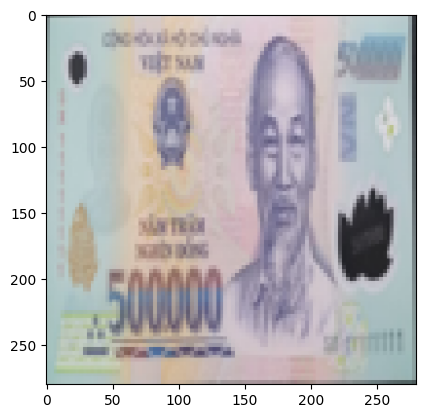

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Tờ này là tờ :500k


In [ ]:
from keras.utils import load_img
import numpy as np
import matplotlib.pyplot as plt

path='/content/500k.png'
img=load_img(path,target_size=(280,280))
plt.imshow(img)
plt.show()
img=np.array(img)
img=img/255.0
img=np.expand_dims(img, axis=0)
prediction=np.argmax(model.predict(img))
class_labels={v:k for k,v in train_generator.class_indices.items()}
ten=class_labels[prediction]
print(f'Tờ này là tờ :{ten}')